<a href="https://colab.research.google.com/github/majishah/MAAR_Stream/blob/main/Adaptability_Household_Drift_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
  import pandas as pd
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt

In [ ]:
src_minute = "/content/drive/MyDrive/2019PHD11006/Datasets/MINUTE_power_consumption_NEW.csv"
src_minute

'/content/drive/MyDrive/2019PHD11006/Datasets/MINUTE_power_consumption_NEW.csv'

In [ ]:
df_minute = pd.read_csv(src_minute, infer_datetime_format=True, parse_dates=['Date_Time'])
df_minute.set_index('Date_Time', drop=False, inplace=True)
df_minute.head()

<ipython-input-4-fc35d7f59c41>:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_minute = pd.read_csv(src_minute, infer_datetime_format=True, parse_dates=['Date_Time'])


,Date_Time,Global_active_power,Global_reactive_power,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power_MA30
Date_Time,,,,,,,,
2006-12-16 17:24:00,2006-12-16 17:24:00,4.216,0.418,18.4,0.0,1.0,17.0,NaN
2006-12-16 17:25:00,2006-12-16 17:25:00,5.360,0.436,23.0,0.0,1.0,16.0,NaN
2006-12-16 17:26:00,2006-12-16 17:26:00,5.374,0.498,23.0,0.0,2.0,17.0,NaN
2006-12-16 17:27:00,2006-12-16 17:27:00,5.388,0.502,23.0,0.0,1.0,17.0,NaN
2006-12-16 17:28:00,2006-12-16 17:28:00,3.666,0.528,15.8,0.0,1.0,17.0,NaN


In [ ]:
df_minute[df_minute['Date_Time']=='2006-12-16 17:24:00']

,Date_Time,Global_active_power,Global_reactive_power,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power_MA30
Date_Time,,,,,,,,
2006-12-16 17:24:00,2006-12-16 17:24:00,4.216,0.418,18.4,0.0,1.0,17.0,NaN


In [ ]:
newdf=df_minute[['Global_active_power']]
newdf

,Global_active_power
Date_Time,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666
...,...
2010-11-26 20:58:00,0.946
2010-11-26 20:59:00,0.944
2010-11-26 21:00:00,0.938


In [ ]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i==0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1)) for j in range(n_vars)]
        agg = pd.concat(cols, axis=1)
        agg.columns = names
        if dropnan:
            agg.dropna(inplace=True)
        return agg

In [ ]:
reframed = series_to_supervised(newdf.values, 90, 1)
reframed.head()

,var1(t-90),var1(t-89),var1(t-88),var1(t-87),var1(t-86),var1(t-85),var1(t-84),var1(t-83),var1(t-82),var1(t-81),...,var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1),var1(t)
0,4.298,2.448,2.322,2.336,2.496,2.540,2.786,4.218,4.204,4.200,...,3.662,3.668,3.700,3.702,3.520,3.666,5.388,5.374,5.360,4.216
1,4.230,4.298,2.448,2.322,2.336,2.496,2.540,2.786,4.218,4.204,...,4.448,3.662,3.668,3.700,3.702,3.520,3.666,5.388,5.374,5.360
2,4.230,4.230,4.298,2.448,2.322,2.336,2.496,2.540,2.786,4.218,...,5.412,4.448,3.662,3.668,3.700,3.702,3.520,3.666,5.388,5.374
3,3.924,4.230,4.230,4.298,2.448,2.322,2.336,2.496,2.540,2.786,...,5.224,5.412,4.448,3.662,3.668,3.700,3.702,3.520,3.666,5.388
4,4.218,3.924,4.230,4.230,4.298,2.448,2.322,2.336,2.496,2.540,...,5.268,5.224,5.412,4.448,3.662,3.668,3.700,3.702,3.520,3.666


In [ ]:
  # Take 1 day of data (1440 samples)
df = reframed.iloc[0:1440]
print("df shape:", df.shape)

df shape: (1440, 91)


In [ ]:
# Features: all columns except the target var1(t)
X = df.drop(columns=['var1(t)'])
y = df['var1(t)']

In [ ]:
# Temporal train-test split (80% train, 20% test)
train_size = int(0.8 * len(df))  # 1152 samples
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

X_train shape: (1152, 90) y_train shape: (1152,)
X_test shape: (288, 90) y_test shape: (288,)


In [ ]:
!pip install river

  Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.1.4
    Uninstalling pandas-2.1.4:
      Successfully uninstalled pandas-2.1.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sktime 0.26.0 requires pandas<2.2.0,>=1.1, but you have pandas 2.2.3 which is incompatible.
pycaret 3.3.2 requires pandas<2.

In [ ]:
from river import drift
from river.linear_model import LinearRegression
from river.optim import SGD
from river.optim.schedulers import Constant
from river.metrics import MSE
from river.stream import iter_pandas
from river.preprocessing import StandardScaler  # Added

# Initialize LinearRegression model for autoregression
model_lr = (

    LinearRegression(optimizer=SGD())
)

# Initialize metric
metric_lr = MSE()

# Optional: Drift detector for adaptability
drift_detector = drift.ADWIN()

# Prequential evaluation
data_stream = iter_pandas(X, y)
lr_mse_history = []

for i, (x, y_true) in enumerate(data_stream):
    # Predict
    y_pred = model_lr.predict_one(x)

    # Update metric
    if y_pred is not None:
        metric_lr.update(y_true, y_pred)
        lr_mse_history.append(metric_lr.get())

        # Update drift detector
        error = abs(y_true - y_pred)
        drift_detector.update(error)
        if drift_detector.drift_detected:
            print(f"LinearRegression: Drift detected at sample {i + 1}")
            # Reset model
            model_lr = (

                LinearRegression(optimizer=SGD())
            )

    # Train
    model_lr.learn_one(x, y_true)

    # Print progress
    if (i + 1) % 30 == 0:
        print(f"LinearRegression - Samples: {i + 1}, MSE: {metric_lr.get()}")

print(f"LinearRegression - Final MSE: {metric_lr.get()}")

LinearRegression - Samples: 30, MSE: 5.2323607601454015e+25
LinearRegression - Samples: 60, MSE: 5.513743364259346e+25
LinearRegression - Samples: 90, MSE: 5.295926896368897e+25
LinearRegression - Samples: 120, MSE: 5.100582813988717e+25
LinearRegression - Samples: 150, MSE: 4.900965958552273e+25
LinearRegression - Samples: 180, MSE: 4.658188616352656e+25
LinearRegression - Samples: 210, MSE: 4.392980280129673e+25
LinearRegression - Samples: 240, MSE: 4.105412247916796e+25
LinearRegression - Samples: 270, MSE: 3.7623777096245458e+25
LinearRegression - Samples: 300, MSE: 3.429788274094896e+25
LinearRegression: Drift detected at sample 320
LinearRegression - Samples: 330, MSE: 3.1363220613988768e+25
LinearRegression - Samples: 360, MSE: 2.9069029496807405e+25
LinearRegression: Drift detected at sample 384
LinearRegression - Samples: 390, MSE: 2.719387345201981e+25
LinearRegression - Samples: 420, MSE: 2.6416667601609537e+25
LinearRegression - Samples: 450, MSE: 2.6110270438878637e+25
Lin

In [ ]:
  train=reframed.drop("var1(t-90)",axis=1)
  test=reframed[["var1(t-90)"]]
  test

,var1(t-90)
0,4.298
1,4.230
2,4.230
3,3.924
4,4.218
...,...
2075164,0.946
2075165,0.944
2075166,0.938
2075167,0.934


In [ ]:
  !pip install pycaret

  Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached scipy-1.11.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
Using cached scipy-1.11.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (36.4 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
river 0.22.0 requires pandas<3.0.0,>=2.2.3, but you have pandas 2.1.4 which is incompatible.
river 0.22.0 requires scipy<2.0

In [ ]:
  import jinja2
  from pycaret.regression import setup, compare_models, pull, predict_model, finalize_model

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b046bb854e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


In [ ]:
target = test.columns[0]
numeric_features = x.columns.tolist()
target

'var1(t-90)'

In [ ]:
  from datetime import datetime

In [ ]:
from pycaret.regression import setup, compare_models, finalize_model

# Setup the environment
s = setup(data = df, target = "var1(t-90)", session_id = 123)

# Use the 'include' parameter to limit the models being compared,
# or adjust 'fold' parameter to reduce computation. This won't exactly stop at 80%,
# but it's a way to manage computation time.
# Here, you can specify a subset of models to reduce the computation load.
# Adjusting this list or other parameters can indirectly affect the total computation time.
models_to_compare = ['et', 'xgboost', 'rf','gbr','huber','lr','ridge','br','lar','omp']  # Example: Only include linear regression, decision tree, and random forest

best = compare_models(include=models_to_compare, sort='MAE', fold=5)  # Adjust 'fold' to control execution time

final_best_model = finalize_model(best)


,Description,Value
0,Session id,123
1,Target,var1(t-90)
2,Target type,Regression
3,Original data shape,"(1440, 91)"
4,Transformed data shape,"(1440, 91)"
5,Transformed train set shape,"(1007, 91)"
6,Transformed test set shape,"(433, 91)"
7,Numeric features,90
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3514,0.3056,0.5516,0.7604,0.1982,0.3205,2.9520
rf,Random Forest Regressor,0.3765,0.3394,0.5817,0.7339,0.2084,0.3414,4.2620
xgboost,Extreme Gradient Boosting,0.3835,0.3656,0.6038,0.7129,0.2112,0.3305,2.4660
gbr,Gradient Boosting Regressor,0.4062,0.3780,0.6141,0.7032,0.2187,0.3606,2.0700
omp,Orthogonal Matching Pursuit,0.4317,0.4172,0.6443,0.6708,0.2386,0.3912,0.0320
huber,Huber Regressor,0.4419,0.4456,0.6664,0.6486,0.2469,0.3924,0.0880
br,Bayesian Ridge,0.4609,0.4495,0.6695,0.6464,0.2440,0.4108,0.0320
ridge,Ridge Regression,0.4681,0.4651,0.6809,0.6346,0.2459,0.4068,0.0300
lr,Linear Regression,0.4685,0.4660,0.6815,0.6339,0.2461,0.4069,0.0320
lar,Least Angle Regression,0.4862,0.4912,0.7001,0.6133,0.2506,0.4120,0.0460


Processing:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_squared_log_error, mean_absolute_percentage_error

In [ ]:
final_best_model.fit(x,y)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['var1(t-89)', 'var1(t-88)',
                                             'var1(t-87)', 'var1(t-86)',
                                             'var1(t-85)', 'var1(t-84)',
                                             'var1(t-83)', 'var1(t-82)',
                                             'var1(t-81)', 'var1(t-80)',
                                             'var1(t-79)', 'var1(t-78)',
                                             'var1(t-77)', 'var1(t-76)',
                                             'var1(t-75)', 'var1(t-74)',
                                             'var1(t-73)', 'var1(t-72)',
                                             'var1(t-71)', 'var1(t-7...
                                             'var1(t-65)', 'var1(t-64)',
                                             'var1(t-63)', 'var1(t-62)',
                                             'var1(t-61)', 'var1(t-60)', ...],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('clean_column_names',
                 TransformerWrapper(transformer=CleanColumnNames())),
                ('actual_estimator',
                 ExtraTreesRegressor(n_jobs=-1, random_state=123))])

In [ ]:
final_best_model.predict(x)

array([4.29799986, 4.23000002, 4.23000002, ..., 3.80999994, 3.80800009,
       3.97799993])

In [ ]:
  x=train.iloc[0:1440]
  final_best_model.predict(x)

array([4.29799986, 4.23000002, 4.23000002, ..., 3.80999994, 3.80800009,
       3.97799993])

In [ ]:
def automodel(data):
  s = setup(data = data, target = "var1(t-90)",session_id = 123)

  models_to_compare = ['et', 'xgboost', 'rf','gbr','huber','lr','ridge','br','lar','omp']
  best = compare_models(include=models_to_compare, sort='MAE', fold=5)
  #best = compare_models(sort='MAE')
  best_model = finalize_model(best)
  return best_model

In [ ]:
ph = PageHinkley(min_instances=60, threshold=5) # method 1 - page hinkley
ad = ADWIN(delta=0.004) # method 2 - adaptive window
ks = KSWIN(alpha=0.001, window_size=500, stat_size=150, data=None) # method 6 - Kolmogorov-Smirnov Windowing method

methods = {"page-hinkley":ph, "adaptive-window":ad, "Kolmogorov-Smirnov":ks}
drift_det = {"page-hinkley":0, "adaptive-window":0, "Kolmogorov-Smirnov":0}

In [ ]:
drift_count = 0  # Initialize drift counter outside the loops

for val in y.values.flatten():
    for i, dd in methods.items():
        dd.add_element(val)
        if dd.detected_change():
            drift_count += 1  # Increment drift counter
            print(f"Drift Detected at {val}, Total Drifts: {drift_count}")


Drift Detected at 2.334, Total Drifts: 1
Drift Detected at 0.852, Total Drifts: 2
Drift Detected at 0.384, Total Drifts: 3
Drift Detected at 2.456, Total Drifts: 4
Drift Detected at 5.282, Total Drifts: 5
Drift Detected at 0.388, Total Drifts: 6
Drift Detected at 2.022, Total Drifts: 7
Drift Detected at 0.288, Total Drifts: 8
Drift Detected at 3.434, Total Drifts: 9
Drift Detected at 2.306, Total Drifts: 10
Drift Detected at 2.94, Total Drifts: 11
Drift Detected at 6.926, Total Drifts: 12
Drift Detected at 2.308, Total Drifts: 13
Drift Detected at 3.49, Total Drifts: 14
Drift Detected at 3.016, Total Drifts: 15
Drift Detected at 2.978, Total Drifts: 16
Drift Detected at 3.81, Total Drifts: 17
Drift Detected at 1.788, Total Drifts: 18
Drift Detected at 2.122, Total Drifts: 19
Drift Detected at 2.238, Total Drifts: 20
Drift Detected at 2.88, Total Drifts: 21
Drift Detected at 4.912, Total Drifts: 22
Drift Detected at 2.802, Total Drifts: 23
Drift Detected at 3.058, Total Drifts: 24
Drift

In [ ]:
k=1441*2
l=[]
d=0
for i in range(1,2):
  x=train.iloc[k*i:k*(i+1)]
  y=test.iloc[k*i:k*(i+1)]
  dfval=y.values.flatten()
  c=0
  for j in range(1,1440):
    val=dfval[j-1]
    for s, dd in methods.items():
      dd.add_element(val)
      if dd.detected_change():
        h=train.iloc[k*i:(k*i)+j]
        hp=test.iloc[k*i:(k*i)+j]
        pred=final_best_model.predict(h)
        mae=mean_absolute_error(hp,pred)
        if mae>0.2:
          print(f"drift detected and performance degraded below threshold, so we are updating model based on AutoML")
          d=k+j
          windf=reframed.iloc[d-1440:d]
          x_val=train.iloc[d-1440:d]
          y_val=test.iloc[d-1440:d]
          model=automodel(windf)
          model.fit(x_val,y_val)
          final_best_model=model
          k=d
        else:
          print(f"drift detected but peformance is good with mae:{mae}")


drift detected and performance degraded below threshold, so we are updating model based on AutoML


,Description,Value
0,Session id,123
1,Target,var1(t-90)
2,Target type,Regression
3,Original data shape,"(1440, 91)"
4,Transformed data shape,"(1440, 91)"
5,Transformed train set shape,"(1007, 91)"
6,Transformed test set shape,"(433, 91)"
7,Numeric features,90
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0817,0.0447,0.2073,0.9626,0.0678,0.0552,0.9700
huber,Huber Regressor,0.0825,0.0505,0.2159,0.9579,0.0690,0.0550,0.0340
rf,Random Forest Regressor,0.0867,0.0509,0.2172,0.9574,0.0683,0.0557,0.9180
omp,Orthogonal Matching Pursuit,0.0876,0.0505,0.2174,0.9577,0.0707,0.0652,0.0160
gbr,Gradient Boosting Regressor,0.0935,0.0561,0.2281,0.9531,0.0717,0.0678,0.5280
xgboost,Extreme Gradient Boosting,0.0940,0.0557,0.2292,0.9536,0.0700,0.0599,0.8280
br,Bayesian Ridge,0.1042,0.0536,0.2254,0.9552,0.0741,0.0787,0.0160
ridge,Ridge Regression,0.1067,0.0549,0.2284,0.9541,0.0754,0.0807,0.0180
lr,Linear Regression,0.1104,0.0568,0.2330,0.9524,0.0774,0.0841,0.0160
lar,Least Angle Regression,0.1767,0.1107,0.3246,0.9052,0.1157,0.1441,0.0220


Processing:   0%|          | 0/45 [00:00<?, ?it/s]

drift detected and performance degraded below threshold, so we are updating model based on AutoML


...

drift detected but peformance is good with mae:0.053097222222222226
drift detected but peformance is good with mae:0.055162687499999995
drift detected but peformance is good with mae:0.0891858522727273
drift detected but peformance is good with mae:0.09024675900277007
drift detected but peformance is good with mae:0.11748980769230764
drift detected but peformance is good with mae:0.13209330357142854
drift detected but peformance is good with mae:0.17623999999999992
drift detected and performance degraded below threshold, so we are updating model based on AutoML


,Description,Value
0,Session id,123
1,Target,var1(t-90)
2,Target type,Regression
3,Original data shape,"(1440, 91)"
4,Transformed data shape,"(1440, 91)"
5,Transformed train set shape,"(1007, 91)"
6,Transformed test set shape,"(433, 91)"
7,Numeric features,90
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.1389,0.1034,0.3185,0.9337,0.0943,0.0931,0.3140
rf,Random Forest Regressor,0.1451,0.1109,0.3301,0.9285,0.0980,0.0974,1.0320
huber,Huber Regressor,0.1511,0.1218,0.3462,0.9211,0.1052,0.1141,0.0360
xgboost,Extreme Gradient Boosting,0.1536,0.1141,0.3352,0.9272,0.1021,0.1075,0.4600
gbr,Gradient Boosting Regressor,0.1618,0.1188,0.3424,0.9238,0.1038,0.1175,0.5520
omp,Orthogonal Matching Pursuit,0.1659,0.1250,0.3519,0.9186,0.1119,0.1343,0.0160
br,Bayesian Ridge,0.1799,0.1284,0.3563,0.9165,0.1191,0.1661,0.0200
ridge,Ridge Regression,0.1897,0.1332,0.3635,0.9134,0.1240,0.1827,0.0180
lr,Linear Regression,0.1920,0.1346,0.3655,0.9125,0.1251,0.1866,0.0200
lar,Least Angle Regression,0.4319,0.6207,0.6948,0.5827,0.2322,0.5146,0.0220


Processing:   0%|          | 0/45 [00:00<?, ?it/s]

drift detected but peformance is good with mae:0.17321590673575127
drift detected but peformance is good with mae:0.16816879999999998
drift detected but peformance is good with mae:0.16625928483353883
drift detected but peformance is good with mae:0.17505249097472922
drift detected but peformance is good with mae:0.17511105769230764
drift detected but peformance is good with mae:0.1732569444444444
drift detected but peformance is good with mae:0.1592757916666666
drift detected but peformance is good with mae:0.15820892783505153
drift detected but peformance is good with mae:0.18060768303186903
drift detected but peformance is good with mae:0.17942612179487175
drift detected but peformance is good with mae:0.1786692721518987
drift detected but peformance is good with mae:0.18304516369047613
drift detected but peformance is good with mae:0.18879401030169238
drift detected but peformance is good with mae:0.1899394602272727


In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 8.3 MB/s eta 0:00:00


PermutationExplainer explainer: 101it [00:25,  2.74it/s]


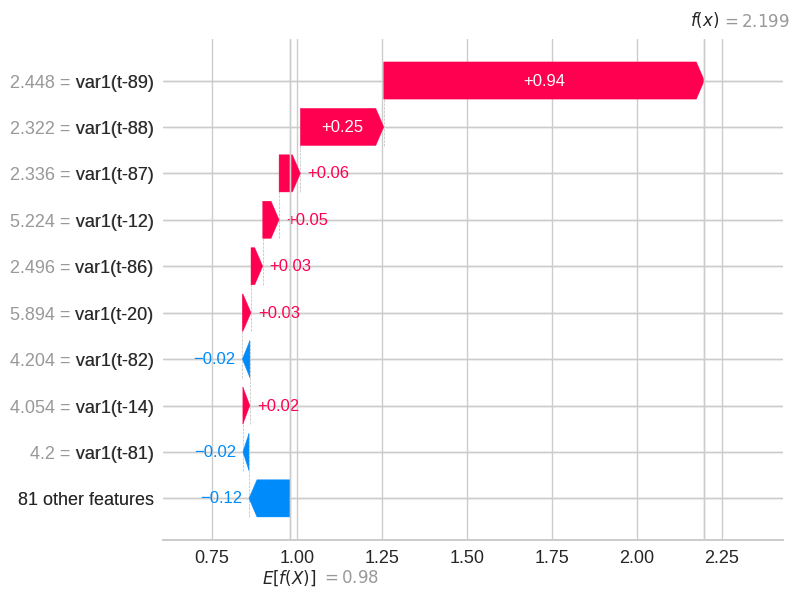

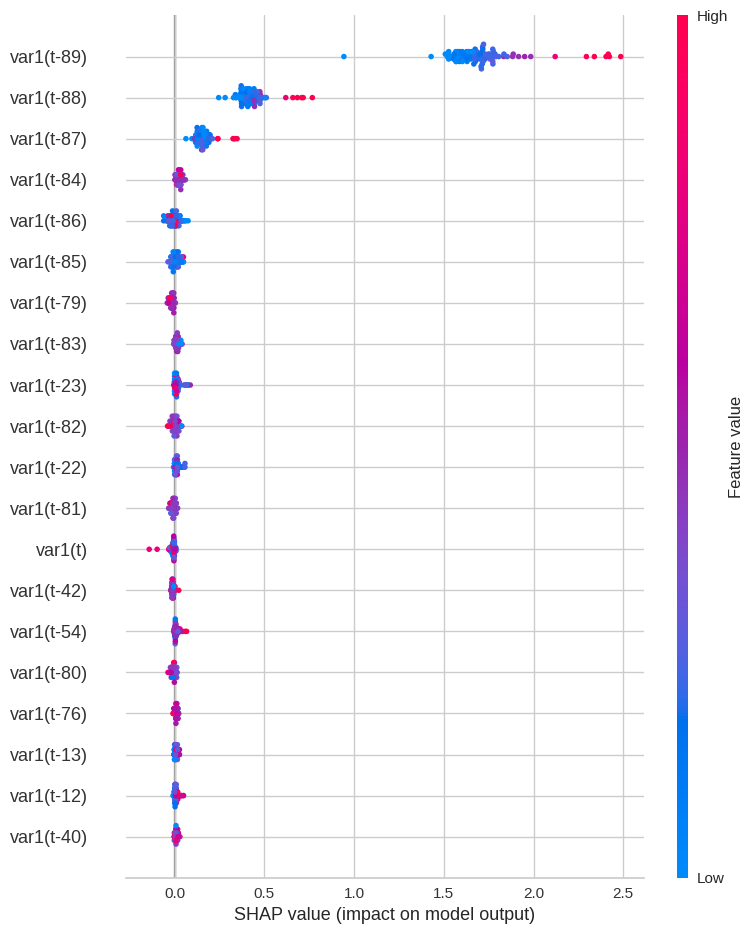

In [ ]:
import shap
explainer = shap.Explainer(final_best_model.predict, train)

# Select a subset of the data for interpretation
x_val = train.iloc[:100]

# Calculate SHAP values
shap_values = explainer(x_val)

# Plot SHAP values for a single prediction
shap.plots.waterfall(shap_values[0])

# Summary plot for feature importance
shap.summary_plot(shap_values, x_val)